# Cointegration Analysis of System without Cointegration.

The analysis will be performed on a VAR(n) model.

In [34]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot
import numpy

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import var, stats, vecm, adf, arima
from lib.plots import stack, fpoints, fcurve, PlotType, comparison, comparison_stack

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [35]:
def var_plot(xt, title, ylim=(-2.5, 2.5), xlim=(0, 1000)):
    ylabels = [f"$S_{i+1}(t)$" for i in range(len(xt))]
    stack(xt, ylim=ylim, xlim=xlim, title=title, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), title_offset=0.2, lw=1)

def integrated_var_plot(xt, title):
    labels = [r"$x_1$", r"$x_2$", r"$x_3$"]   
    comparison(xt, labels =labels, title=title, xlabel=r"$t$", lw=1, title_offset=0.05)

def adf_test(xt):
    for i in range(len(xt)):
        result, _ = adf.compute_adf_test(xt[i])
        if result.status_vals[1]:
            print("Not Stationary")
        else:
            print("Stationary")

def pacf_acf_plot(t, dxt, nlags, title):
    acf = [stats.compute_acf(t, samp, nlags=nlags) for samp in dxt] 
    pacf = [arima.compute_pacf(samp, nlags=nlags) for samp in dxt]
    data = [[acf[i][1], pacf[i][1]] for i in range(len(dxt))]
    time = [[acf[i][0], pacf[i][0]] for i in range(len(dxt))]
    comparison_stack(data, time, title=title, xlabel=r"Lag", ylim=(-0.25, 1.0), figsize=(10, 8), 
                     labels=[["ACF", "PACF"]], ylabels=[r"$\Delta x_1$", r"$\Delta x_2$", r"$\Delta x_3$"])

In [20]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.0, 0.15],
                      [0.25, 0.15, 0.0],
                      [0.0, 0.25, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])

npts=1000
var.compute_is_stationary(phi)

True

In [21]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

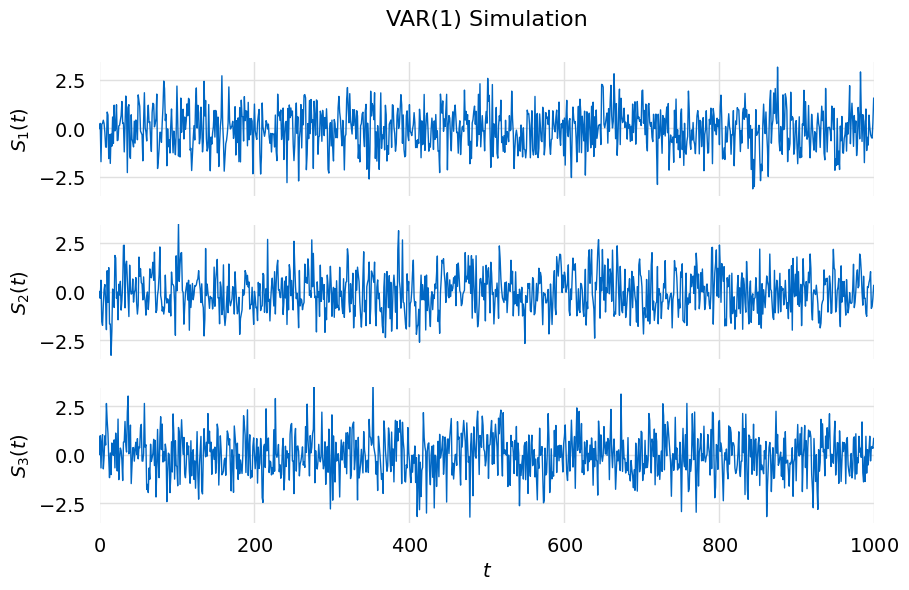

In [22]:
title = f"VAR(1) Simulation"
var_plot(xt, title, ylim=(-3.5, 3.5))

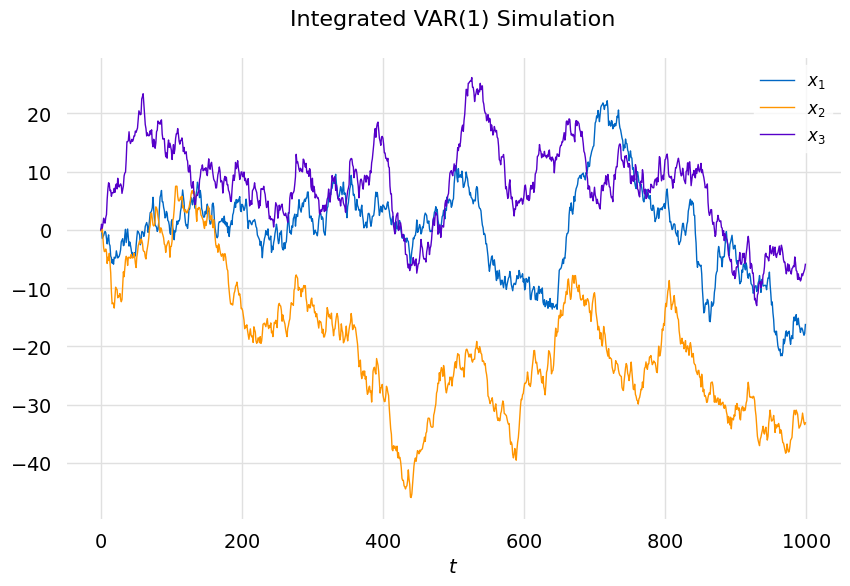

In [23]:
title = f"Integrated VAR(1) Simulation"
ixt = numpy.cumsum(xt, axis=1)
integrated_var_plot(ixt, title)

### Stationarity Test

In [27]:
adf_test(ixt)

Not Stationary
Not Stationary
Not Stationary


In [28]:
dt, dxt = stats.compute_diff(t, ixt)
adf_test(dxt)

Stationary
Stationary
Stationary


### Order Determination

In [39]:
result, result_model = vecm.compute_order(ixt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.2864,0.3603,1.332,0.3145
1,0.1097*,0.2279*,1.116*,0.1546*
2,0.1237,0.2863,1.132,0.1855
3,0.1298,0.3367,1.139,0.2085
4,0.1386,0.3899,1.149,0.2341


In [40]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "8d26fcf4-8bd8-4afc-9ba3-3d70b610e0c2",
   "_VAROrderTestReport__order": {
      "test_id": "8d26fcf4-8bd8-4afc-9ba3-3d70b610e0c2",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "8d26fcf4-8bd8-4afc-9ba3-3d70b610e0c2",
      "order": {
         "test_id": "8d26fcf4-8bd8-4afc-9ba3-3d70b610e0c2",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "8d26fcf4-8bd8-4afc-9ba3-3d70b610e0c2",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.10967521298234237
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "8d26fcf4-8bd8-4afc-9ba3-3d70b610e0c2",
      "order": {
         "test_id": "8d26fcf4-8bd8-4afc-9ba3-3d70b610e0c2",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "8d26fcf4-8bd8-4afc-9ba3-3d70b610e0c2",
        

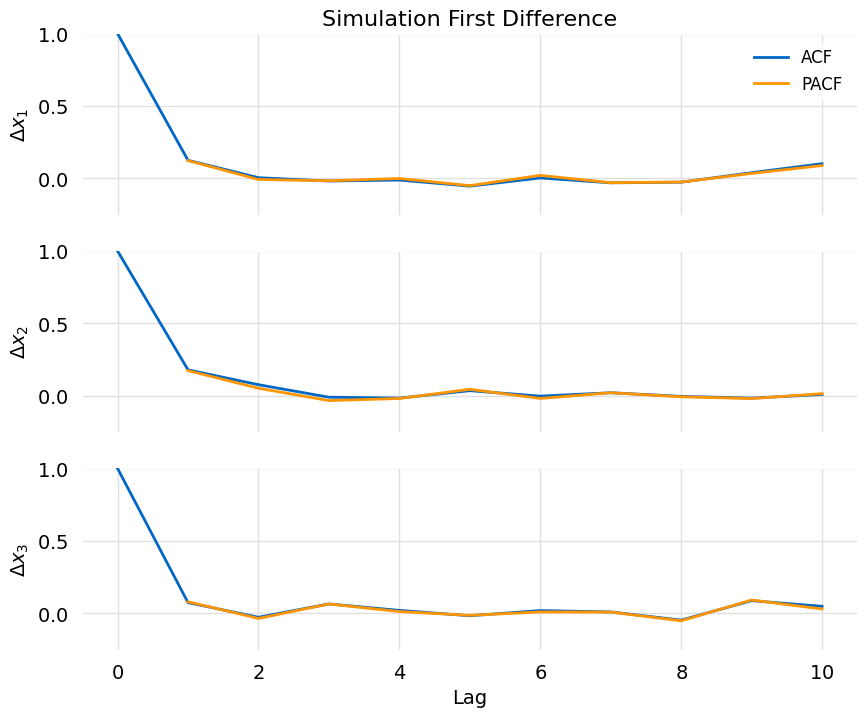

In [36]:
nlags = 10
title = f"Simulation First Difference"
pacf_acf_plot(t, xt, 10, title)

### Granger Causality

In [41]:
result, result_model = stats.compute_causality_matrix(xt, nlags=1)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=997, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=16.0045 , p=0.0001  , df_denom=997, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.7878  , p=0.3750  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=0.7901  , p=0.3741  , df=1
likelihood ratio test: chi2=0.7898  , p=0.3742  , df=1
parameter F test:         F=0.7878  , p=0.3750  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=22.0218 , p=0.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=22.0881 , p=0.0000  , df=1
likelihood ratio test: chi2=21.8474 , p=0.0000  , df=1
parameter F test:         F=22.0218 , p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=46.0849 , p=0.0000  

In [42]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.3750,0.05,False,1,2
3,0.0000,0.05,True,1,3
4,0.0000,0.05,True,2,1
5,1.0000,0.05,False,2,2
6,0.7839,0.05,False,2,3
7,0.7344,0.05,False,3,1
8,0.0000,0.05,True,3,2
9,1.0000,0.05,False,3,3


In [43]:
print(result_model.to_json(pretty=True))

{
   "test_id": "62d30d01-96d2-46c2-9ffd-076b3546a543",
   "rank": 3,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "62d30d01-96d2-46c2-9ffd-076b3546a543",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "62d30d01-96d2-46c2-9ffd-076b3546a543",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.375,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "62d30d01-96d2-46c2-9ffd-076b3546a543",
         "_GrangerCausalityTestResult__dep

### Johansen Test for Cointegration

In [89]:
result, result_model, _ = vecm.compute_johansen_coint_test(ixt, 1)

In [90]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │           25.893 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │           10.752 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            3.674 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [46]:
print(result_model.to_json(pretty=True))

{
   "test_id": "c403f04a-ebc5-4e2c-b6ea-869f96c559c3",
   "trace_test": [
      {
         "test_id": "c403f04a-ebc5-4e2c-b6ea-869f96c559c3",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 25.893010539538963,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            false,
            false,
            false
         ]
      },
      {
         "test_id": "c403f04a-ebc5-4e2c-b6ea-869f96c559c3",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 10.752436147981781,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Va